In [1]:
# ---
# jupyter:
#   jupytext:
#     text_representation:
#       extension: .py
#       format_name: percent
# ---

# 필요 패키지: plotly>=6, kaleido  (torch 불필요 — 전부 순수 파이썬)

# DINO 손실 항 개수 $|\mathcal{N}|$ 계산하기

DINO의 목적함수는 한 이미지 $x$에서 만든 view 집합

$$
V = \underbrace{\{x_1^{g},\, x_2^{g}\}}_{V^{g}\ (\text{global, 224px})}
    \ \cup\ \underbrace{\{x_1^{l},\dots,x_{N}^{l}\}}_{\text{local, 96px}}
$$

위에서 **교사 $\times$ 학생** 쌍을 전부 훑는다:

$$
\mathcal{L} = \frac{1}{|\mathcal{N}|}\sum_{u\in V^{g}}\ \sum_{\substack{v\in V\\ v\neq u}}
  H\big(P_{\theta_t}(u),\, P_{\theta_s}(v)\big)
$$

여기서 항의 개수는

$$
|\mathcal{N}| = \underbrace{2}_{\text{교사 view}} \times \underbrace{(2+N)}_{\text{학생 view}}
                \;-\; \underbrace{2}_{v = u\ \text{인 쌍}}
             \;=\; 2(2+N) - 2
$$

세 개의 숫자가 각각 어디서 오는지가 전부다:

| 인자 | 값 | 이유 |
|---|---|---|
| 교사 view 수 | $2$ | 교사는 **global view만** 본다 ($u \in V^g$) |
| 학생 view 수 | $2+N$ | 학생은 **전부** 본다 ($v \in V$) |
| 빼는 항 | $2$ | $v = u$ 인 자명한 쌍 (global 2개 각각 자기 자신) |

아래에서 이중 루프로 직접 세어서 공식과 대조해 본다.

In [2]:
import os

import plotly.graph_objects as go
from plotly.subplots import make_subplots


def _show(fig):
    try:
        from IPython import get_ipython
        if get_ipython() is not None:  # VSCode 셀/Jupyter에서만 렌더링
            fig.show()
    except ImportError:
        pass


HERE = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()
print("저장 경로:", HERE)

저장 경로: /home/sungwoo/projects/swcho/dino/fm/training/.fm/hints/8afa5865-e243-4c59-8234-02d3c0dda25d


## 1. view에 이름 붙이기

학생이 보는 view 리스트의 **순서**가 중요하다. `DataAugmentationDINO.__call__`은
항상 `[global1, global2, local1, ..., localN]` 순서의 리스트를 만들고,
교사는 그중 앞의 2개(global)만 받는다.

즉 학생 인덱스 `0, 1`과 교사 인덱스 `0, 1`이 **같은 crop을 가리킨다**.
이 정렬 덕분에 "제외할 쌍"이 정확히 대각선 2칸으로 떨어진다.

In [3]:
def make_views(N):
    """학생이 보는 view 이름 리스트 (길이 2+N). 앞 2개가 global."""
    return ["g1", "g2"] + [f"l{i}" for i in range(1, N + 1)]


N = 8
student_views = make_views(N)          # 학생: 전부 본다
teacher_views = student_views[:2]      # 교사: global 2개만 본다

print(f"N = {N}")
print(f"학생 view ({len(student_views)}개): {student_views}")
print(f"교사 view ({len(teacher_views)}개): {teacher_views}")

N = 8
학생 view (10개): ['g1', 'g2', 'l1', 'l2', 'l3', 'l4', 'l5', 'l6', 'l7', 'l8']
교사 view (2개): ['g1', 'g2']


## 2. 이중 루프로 $(u, v)$ 쌍 열거하기

`main_dino.py`의 `DINOLoss.forward`와 똑같은 규칙이다:

```python
for iq, q in enumerate(teacher_out):       # iq = 0, 1  (교사 global 2개)
    for v in range(len(student_out)):      # v = 0 .. 2+N-1
        if v == iq:
            continue                       # 같은 view 쌍은 건너뛴다
        n_loss_terms += 1
```

In [4]:
def enumerate_pairs(N):
    """(교사 인덱스, 학생 인덱스, 사용 여부) 를 전부 열거."""
    views = make_views(N)
    pairs = []
    for iq in range(2):                     # 교사는 global 2개뿐
        for v in range(len(views)):         # 학생은 2+N개 전부
            pairs.append((iq, v, v != iq))  # v == iq 이면 제외
    return pairs, views


pairs, views = enumerate_pairs(N)
used = [p for p in pairs if p[2]]
skipped = [p for p in pairs if not p[2]]

print(f"전체 쌍   = {len(pairs):>2}   ( 2 x (2+{N}) = {2 * (2 + N)} )")
print(f"제외된 쌍 = {len(skipped):>2}   {[(views[u], views[v]) for u, v, _ in skipped]}")
print(f"손실 항   = {len(used):>2}   <-- |N|")
print(f"공식 2(2+N)-2 = {2 * (2 + N) - 2}   일치? {len(used) == 2 * (2 + N) - 2}")

전체 쌍   = 20   ( 2 x (2+8) = 20 )
제외된 쌍 =  2   [('g1', 'g1'), ('g2', 'g2')]
손실 항   = 18   <-- |N|
공식 2(2+N)-2 = 18   일치? True


In [5]:
# 18개 항이 실제로 어떤 (교사 u, 학생 v) 쌍인지 전부 찍어 보기
for k, (u, v, _) in enumerate(used, start=1):
    kind = "global->global" if v < 2 else "global->local "
    print(f"  항 {k:>2}: H( P_t({views[u]}) , P_s({views[v]}) )   {kind}")

  항  1: H( P_t(g1) , P_s(g2) )   global->global
  항  2: H( P_t(g1) , P_s(l1) )   global->local 
  항  3: H( P_t(g1) , P_s(l2) )   global->local 
  항  4: H( P_t(g1) , P_s(l3) )   global->local 
  항  5: H( P_t(g1) , P_s(l4) )   global->local 
  항  6: H( P_t(g1) , P_s(l5) )   global->local 
  항  7: H( P_t(g1) , P_s(l6) )   global->local 
  항  8: H( P_t(g1) , P_s(l7) )   global->local 
  항  9: H( P_t(g1) , P_s(l8) )   global->local 
  항 10: H( P_t(g2) , P_s(g1) )   global->global
  항 11: H( P_t(g2) , P_s(l1) )   global->local 
  항 12: H( P_t(g2) , P_s(l2) )   global->local 
  항 13: H( P_t(g2) , P_s(l3) )   global->local 
  항 14: H( P_t(g2) , P_s(l4) )   global->local 
  항 15: H( P_t(g2) , P_s(l5) )   global->local 
  항 16: H( P_t(g2) , P_s(l6) )   global->local 
  항 17: H( P_t(g2) , P_s(l7) )   global->local 
  항 18: H( P_t(g2) , P_s(l8) )   global->local 


18개 중 **2개만 global$\to$global** (교차 쌍 `g1->g2`, `g2->g1`)이고
나머지 **16개가 global$\to$local**이다. 손실의 대부분이 *"작은 조각을 보고
전체를 예측"* 하는 local-to-global 대응에 쓰인다는 뜻이다.

## 3. $N$을 0~12로 바꿔 가며 표로 확인

$|\mathcal{N}| = 2(2+N)-2 = 2N + 2$ 이므로 $N$이 1 늘 때마다 항이 **2개씩** 는다
(교사 global 2개 각각이 새 local view와 짝을 이루므로).

In [6]:
print(f"{'N':>3} | {'학생 view':>9} | {'전체 쌍':>7} | {'제외':>4} | {'|N| (센 값)':>11} | {'2(2+N)-2':>9} | 일치")
print("-" * 70)
rows = []
for n in range(0, 13):
    ps, _ = enumerate_pairs(n)
    counted = sum(1 for p in ps if p[2])
    formula = 2 * (2 + n) - 2
    rows.append((n, counted))
    print(f"{n:>3} | {2 + n:>9} | {len(ps):>7} | {len(ps) - counted:>4} | "
          f"{counted:>11} | {formula:>9} | {'OK' if counted == formula else 'X'}")

  N |   학생 view |    전체 쌍 |   제외 |   |N| (센 값) |  2(2+N)-2 | 일치
----------------------------------------------------------------------
  0 |         2 |       4 |    2 |           2 |         2 | OK
  1 |         3 |       6 |    2 |           4 |         4 | OK
  2 |         4 |       8 |    2 |           6 |         6 | OK
  3 |         5 |      10 |    2 |           8 |         8 | OK
  4 |         6 |      12 |    2 |          10 |        10 | OK
  5 |         7 |      14 |    2 |          12 |        12 | OK
  6 |         8 |      16 |    2 |          14 |        14 | OK
  7 |         9 |      18 |    2 |          16 |        16 | OK
  8 |        10 |      20 |    2 |          18 |        18 | OK
  9 |        11 |      22 |    2 |          20 |        20 | OK
 10 |        12 |      24 |    2 |          22 |        22 | OK
 11 |        13 |      26 |    2 |          24 |        24 | OK
 12 |        14 |      28 |    2 |          26 |        26 | OK


**제외되는 항은 언제나 정확히 2개**다 ($N$과 무관). 교사가 global 2개만 보고,
그 2개가 학생 리스트의 앞 2칸과 같은 crop이기 때문이다.
$N=0$ (local crop 없음)이면 $|\mathcal{N}| = 2$ — global 두 장을 서로 맞추는
항만 남아 사실상 일반적인 2-view self-distillation이 된다.

## 4. $2 \times (2+N)$ 격자로 시각화

행 = 교사 view $u$ (2개), 열 = 학생 view $v$ ($2+N$개).
색이 칠해진 칸이 손실에 들어가는 항이고, 회색 대각 2칸이 `if v == iq: continue`로
잘려 나가는 자명한 쌍이다.

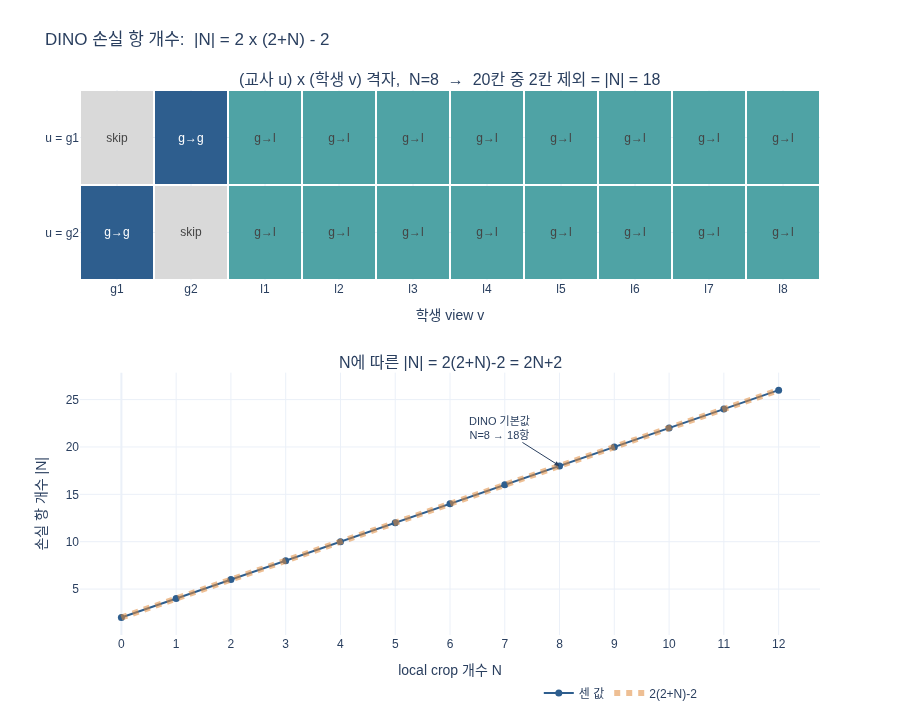

저장: /home/sungwoo/projects/swcho/dino/fm/training/.fm/hints/8afa5865-e243-4c59-8234-02d3c0dda25d/expy.png


In [7]:
Z, TEXT = [], []
for iq in range(2):
    row_z, row_t = [], []
    for v in range(len(views)):
        if v == iq:
            row_z.append(0)                       # 제외
            row_t.append("skip")
        elif v < 2:
            row_z.append(1)                       # global -> global
            row_t.append("g→g")
        else:
            row_z.append(2)                       # global -> local
            row_t.append("g→l")
    Z.append(row_z)
    TEXT.append(row_t)

fig = make_subplots(
    rows=2, cols=1,
    row_heights=[0.42, 0.58],
    vertical_spacing=0.17,
    subplot_titles=(
        f"(교사 u) x (학생 v) 격자,  N={N}  →  20칸 중 2칸 제외 = |N| = 18",
        "N에 따른 |N| = 2(2+N)-2 = 2N+2",
    ),
)

fig.add_trace(
    go.Heatmap(
        z=Z, text=TEXT, texttemplate="%{text}",
        x=views, y=[f"u = {t}" for t in teacher_views],
        colorscale=[[0.0, "#d9d9d9"], [0.33, "#d9d9d9"],
                    [0.34, "#2E5E8E"], [0.66, "#2E5E8E"],
                    [0.67, "#4FA3A5"], [1.0, "#4FA3A5"]],
        zmin=0, zmax=2, showscale=False, xgap=2, ygap=2,
        hovertemplate="교사 %{y}, 학생 v=%{x}<br>%{text}<extra></extra>",
    ),
    row=1, col=1,
)

ns = [r[0] for r in rows]
counts = [r[1] for r in rows]
fig.add_trace(
    go.Scatter(
        x=ns, y=counts, mode="lines+markers", name="센 값",
        line=dict(color="#2E5E8E", width=2), marker=dict(size=7),
        hovertemplate="N=%{x} → |N|=%{y}<extra></extra>",
    ),
    row=2, col=1,
)
fig.add_trace(
    go.Scatter(
        x=ns, y=[2 * (2 + n) - 2 for n in ns], mode="lines", name="2(2+N)-2",
        line=dict(color="#E08A3C", width=6, dash="dot"), opacity=0.55,
        hoverinfo="skip",
    ),
    row=2, col=1,
)
fig.add_annotation(
    x=8, y=18, text="DINO 기본값<br>N=8 → 18항", showarrow=True, arrowhead=2,
    ax=-60, ay=-38, font=dict(size=11), row=2, col=1,
)

fig.update_yaxes(autorange="reversed", row=1, col=1)
fig.update_xaxes(title_text="학생 view v", row=1, col=1)
fig.update_xaxes(title_text="local crop 개수 N", dtick=1, row=2, col=1)
fig.update_yaxes(title_text="손실 항 개수 |N|", row=2, col=1)
fig.update_layout(
    height=720, width=900, template="plotly_white",
    title_text="DINO 손실 항 개수:  |N| = 2 x (2+N) - 2",
    legend=dict(orientation="h", y=-0.08, x=0.62),
    margin=dict(t=90, b=70),
)

_show(fig)
png_path = os.path.join(HERE, "expy.png")
fig.write_image(png_path, scale=2)
print("저장:", png_path)

## 5. `DINOLoss.forward`의 `n_loss_terms` 루프를 그대로 흉내내기

실제 구현(`main_dino.py`)에서는 학생 출력을 `chunk(ncrops)`로 $2+N$조각,
교사 출력을 `chunk(2)`로 2조각으로 쪼갠 뒤 이중 루프를 돈다.
텐서를 "조각 이름 문자열"로 바꾸면 torch 없이 카운트만 똑같이 재현할 수 있다.

In [8]:
def dino_loss_count(ncrops):
    """main_dino.py DINOLoss.forward 의 루프 구조를 그대로 옮긴 카운터."""
    student_out = [f"s[{i}]" for i in range(ncrops)]   # chunk(ncrops)
    teacher_out = [f"t[{i}]" for i in range(2)]        # chunk(2)

    total_loss = 0.0
    n_loss_terms = 0
    for iq, q in enumerate(teacher_out):
        for v in range(len(student_out)):
            if v == iq:
                # we skip cases where student and teacher operate on the same view
                continue
            total_loss += 1.0          # 실제로는 cross-entropy 스칼라 하나
            n_loss_terms += 1
    total_loss /= n_loss_terms         # 평균 → 각 항의 가중치는 1/|N|
    return n_loss_terms, total_loss


for n in (0, 2, 8):
    ncrops = 2 + n                     # DINOLoss(ncrops=local_crops_number + 2)
    n_terms, avg = dino_loss_count(ncrops)
    print(f"N={n:>2}  ncrops={ncrops:>2}  n_loss_terms={n_terms:>2}  "
          f"공식={2 * ncrops - 2:>2}  항당 가중치=1/{n_terms} ({avg:.4f} 확인용)")

N= 0  ncrops= 2  n_loss_terms= 2  공식= 2  항당 가중치=1/2 (1.0000 확인용)
N= 2  ncrops= 4  n_loss_terms= 6  공식= 6  항당 가중치=1/6 (1.0000 확인용)
N= 8  ncrops=10  n_loss_terms=18  공식=18  항당 가중치=1/18 (1.0000 확인용)


## 6. 흔한 함정

- **`ncrops` 인자에 $N$을 넣지 말 것.** `DINOLoss(out_dim, ncrops=2 + 8, ...)`처럼
  `local_crops_number + 2`를 넘겨야 한다. $N$만 넘기면 `chunk(8)`이 되어 학생 배치를
  잘못 쪼개고 항 개수가 $2\cdot8-2 = 14$로 어긋난다.
- **"2를 뺀다"가 대각선 전체를 뺀다는 뜻은 아니다.** $2\times(2+N)$ 격자에서 교사 축이
  2칸뿐이라 대각선 자체가 2칸이다. $N$이 아무리 커져도 빼는 수는 계속 2다.
- **$|\mathcal{N}|$은 이미지 1장 기준.** 배치 크기 $B$면 forward 한 번에
  $18B$개의 cross-entropy가 계산되고, 코드에서는 각 항이 이미 `.mean()`으로
  배치 평균된 뒤 18로 나뉜다.

### 한 줄 요약

$$
|\mathcal{N}| \;=\; \underbrace{2}_{\text{교사}}\times\underbrace{(2+N)}_{\text{학생}} - \underbrace{2}_{v=u}
\;=\; 2N+2 \;\xrightarrow{\;N=8\;}\; 18
$$